In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
#seperate feature and target
#all input features
X = df.drop("DEATH_EVENT", axis=1)

#target variable
y = df["DEATH_EVENT"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (299, 12)
Target shape: (299,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

#predictions
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60



In [5]:
df_fe = df.copy()

df_fe["log_serum_creatinine"] = np.log1p(df_fe["serum_creatinine"])
df_fe["log_creatinine_phosphokinase"] = np.log1p(df_fe["creatinine_phosphokinase"])

df_fe[["serum_creatinine", "log_serum_creatinine",
       "creatinine_phosphokinase", "log_creatinine_phosphokinase"]].head()

,serum_creatinine,log_serum_creatinine,creatinine_phosphokinase,log_creatinine_phosphokinase
0,1.9,1.064711,582,6.368187
1,1.1,0.741937,7861,8.969796
2,1.3,0.832909,146,4.990433
3,1.9,1.064711,111,4.718499
4,2.7,1.308333,160,5.081404


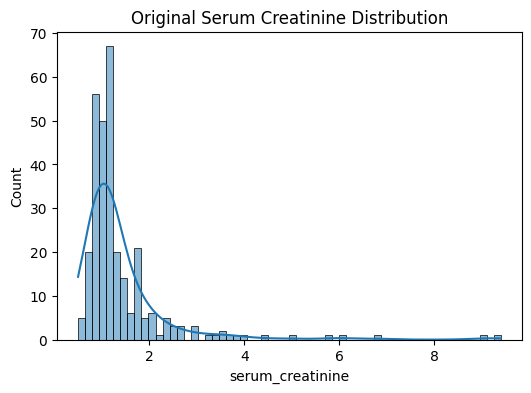

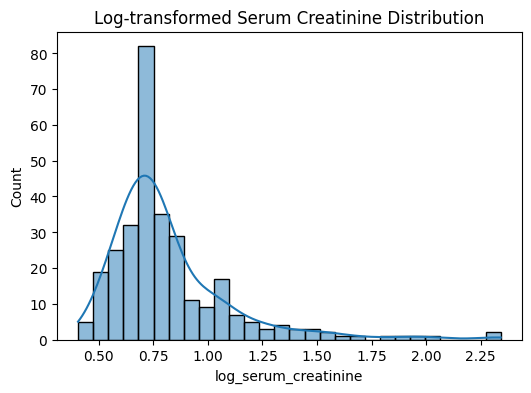

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["serum_creatinine"], kde=True)
plt.title("Original Serum Creatinine Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df_fe["log_serum_creatinine"], kde=True)
plt.title("Log-transformed Serum Creatinine Distribution")
plt.show()

In [7]:
#feature engineering2
#age group
df_fe["age_group"] = pd.cut(
    df_fe["age"],
    bins=[0, 50, 60, 70, 80, 100],
    labels=[0, 1, 2, 3, 4]
)

#convert age group into numeric type
df_fe["age_group"] = df_fe["age_group"].astype(int)

df_fe[["age", "age_group"]].head()


,age,age_group
0,75.0,3
1,55.0,1
2,65.0,2
3,50.0,0
4,65.0,2


In [8]:
df_fe["age_creatinine_interaction"] = df_fe["age"] * df_fe["serum_creatinine"]

#ejection fraction and serum creatinine
df_fe["ef_creatinine_interaction"] = df_fe["ejection_fraction"] * df_fe["serum_creatinine"]

df_fe[["age_creatinine_interaction", "ef_creatinine_interaction"]].head()

,age_creatinine_interaction,ef_creatinine_interaction
0,142.5,38.0
1,60.5,41.8
2,84.5,26.0
3,95.0,38.0
4,175.5,54.0


In [9]:
X_fe = df_fe.drop("DEATH_EVENT", axis=1)
y_fe = df_fe["DEATH_EVENT"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

#train Logistic Regression with engineered features
fe_model = LogisticRegression(max_iter=1000)
fe_model.fit(X_train_fe_scaled, y_train_fe)

#predict
y_pred_fe = fe_model.predict(X_test_fe_scaled)

print("Feature Engineering Model Accuracy:", accuracy_score(y_test_fe, y_pred_fe))
print(classification_report(y_test_fe, y_pred_fe))

Feature Engineering Model Accuracy: 0.7666666666666667
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        35
           1       0.87      0.52      0.65        25

    accuracy                           0.77        60
   macro avg       0.80      0.73      0.74        60
weighted avg       0.79      0.77      0.75        60



In [10]:
baseline_acc = accuracy_score(y_test, y_pred_baseline)
fe_acc = accuracy_score(y_test_fe, y_pred_fe)

comparison = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Feature Engineering Logistic Regression"],
    "Accuracy": [baseline_acc, fe_acc]
})

comparison

,Model,Accuracy
0,Baseline Logistic Regression,0.800000
1,Feature Engineering Logistic Regression,0.766667


In [11]:
coef_df = pd.DataFrame({
    "Feature": X_fe.columns,
    "Coefficient": fe_model.coef_[0]
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(by="Absolute_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Absolute_Coefficient
11,time,-1.711511,1.711511
4,ejection_fraction,-1.053224,1.053224
12,log_serum_creatinine,0.952126,0.952126
16,ef_creatinine_interaction,0.590196,0.590196
15,age_creatinine_interaction,-0.589490,0.589490
0,age,0.421537,0.421537
14,age_group,0.374483,0.374483
9,sex,-0.361663,0.361663
13,log_creatinine_phosphokinase,0.272369,0.272369
8,serum_sodium,-0.233968,0.233968


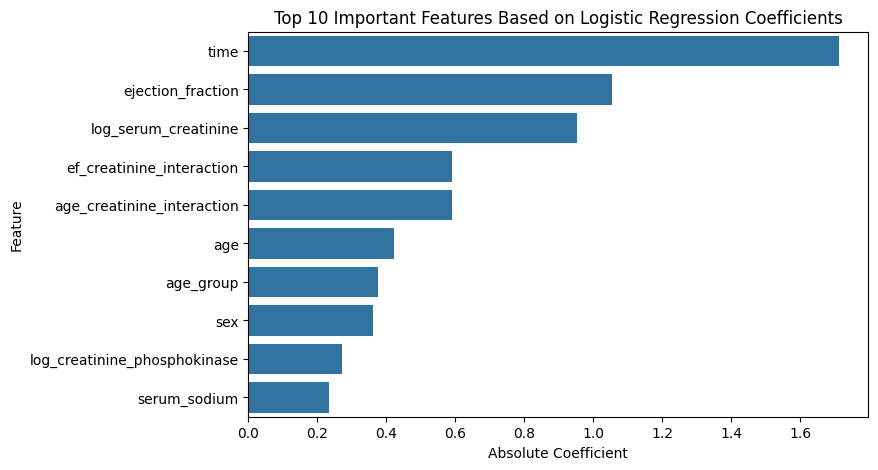

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Absolute_Coefficient",
    y="Feature",
    data=coef_df.head(10)
)
plt.title("Top 10 Important Features Based on Logistic Regression Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()